# 02c: Explore structured site intervals. Volt-Watt / Volt-Var context

Read-only, DuckDB-backed exploration of `structured_site_intervals`.
Nothing is written.

This notebook does three things for one chosen site:

1. Overlays the AS/NZS 4777.2:2020 Australia Region A Volt-Watt and Volt-Var
   default set-points on the site's voltage/power data, and classifies each
   interval's Volt-Var response.
2. Renders a 5-panel single-day "operational modes" plot (voltage, Volt-Watt
   ceiling, Volt-Var required band, and both mechanisms' non-conformance).
3. Traces the P/Q sign convention and DER-phase inference per phase, so an
   unexpected result (e.g. `Q_adverse`) can be checked against the raw
   provider values and the individual phases instead of trusted at face value.

See the module docstring in `voltvar_voltwatt_lib.py` for exactly what was
ported verbatim, what was adapted, and what is deliberately out of scope
(the `S_99` / counterfactual-based Method A curtailment estimate — Ausgrid
Delivery 3 hasn't built an uncurtailed-PV counterfactual yet).

**This is still not a formal conformance assessment:**

- `formal_inverter_conformance_assessable = false` on every row here (see
  `METHODOLOGY_GATES.md`, gate 8). Household load and PV are not decomposed,
  the P/Q sign convention is a working hypothesis, phase-to-inverter mapping
  is inferred (not confirmed), and voltage is measured at the revenue meter,
  not the inverter terminals.
- There is no validated `S_rated` for Ausgrid sites (`DATA_CONTRACT.md`:
  `s_rated_kva` is null). Every %-scaled plot below uses `solar_capacity_kw`
  as an explicitly labelled PROXY and says so on the axis/title — never
  silently as `S_rated`.
- Revenue-meter voltage typically *underestimates* inverter-terminal voltage
  during export (~1-3 V typical, up to 4-5 V on poor installations).


In [2]:
from __future__ import annotations

import sys
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

HERE = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'src' / 'ausgrid_analysis').is_dir()), None)
assert PROJECT_ROOT is not None, 'Start Jupyter inside the ausgrid_analysis project.'
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
sys.path.insert(0, str(PROJECT_ROOT / 'notebooks'))  # for voltvar_voltwatt_lib.py, next to this notebook
from ausgrid_analysis.config import load_config
from ausgrid_analysis.db import (
    site_phase_profile_path,
    site_profile_path,
    structured_phase_output_path,
    structured_site_output_path,
)
from ausgrid_analysis.metadata import metadata_output_path
from ausgrid_analysis.schemas import sql_string
from voltvar_voltwatt_lib import (
    AS4777,
    vw_max_p,
    vvar_required_q,
    plot_vvar_month_scatter_ausgrid,
    plot_operational_ausgrid,
)

pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-whitegrid')

## Select a bounded slice

If `SERIAL=None` chooses a candidate site from the
selected month (a high phase-mapping-confidence site with the most
DER-phase-complete rows). `MAX_ROWS` is a hard guardrail.

The site-scoped query below filters on `site_bucket = mod(hash(serial), N)`
as well as `serial` itself. this lets DuckDB prune to a single hive
partition instead of scanning all ~140M rows / 5.7 GB.

In [3]:
CONFIG_PATH = PROJECT_ROOT / 'analysis.toml'
MONTH = '2024-09'
SERIAL = 810584444
DATE_FROM = None  # local date, e.g. '2025-04-10'
DATE_TO = None    # local date, exclusive
MAX_ROWS = 100_000

config = load_config(CONFIG_PATH, check_inputs=False)
full_scope = config.scope(None, None)
bucket_count = config.processing.site_bucket_count

structured_site_dir = structured_site_output_path(config, full_scope)
assert structured_site_dir.is_dir(), f'Run notebook 02b first: {structured_site_dir}'
structured_site_glob = str(structured_site_dir / '**' / '*.parquet')

site_profile_file = site_profile_path(config, full_scope)
site_phase_profile_file = site_phase_profile_path(config, full_scope)
metadata_file = metadata_output_path(config)

con = duckdb.connect()
con.execute(f"SET memory_limit='{config.processing.memory_limit}'")
con.execute(f"SET threads={min(config.processing.threads, 4)}")
con.execute("SET TimeZone='UTC'")
con.execute(
    f"CREATE VIEW site_intervals AS "
    f"SELECT * FROM read_parquet({sql_string(structured_site_glob)}, hive_partitioning=true)"
)
con.execute(f"CREATE VIEW site_profile AS SELECT * FROM read_parquet({sql_string(site_profile_file)})")
con.execute(
    f"CREATE VIEW site_phase_profile AS SELECT * FROM read_parquet({sql_string(site_phase_profile_file)})"
)
con.execute(f"CREATE VIEW metadata AS SELECT * FROM read_parquet({sql_string(metadata_file)})")

print('structured_site_intervals source:', structured_site_dir)
print('site_profile source:', site_profile_file)
print('site_phase_profile source:', site_phase_profile_file)
print('metadata source:', metadata_file)

structured_site_intervals source: C:\Users\z3553082\OneDrive - UNSW\Documents\CICCADA - Data\Ausgrid\derived\structured_telemetry\structured_site_intervals
site_profile source: C:\Users\z3553082\OneDrive - UNSW\Documents\CICCADA - Data\Ausgrid\derived\structured_telemetry\site_profile.parquet
site_phase_profile source: C:\Users\z3553082\OneDrive - UNSW\Documents\CICCADA - Data\Ausgrid\derived\structured_telemetry\site_phase_profile.parquet
metadata source: C:\Users\z3553082\OneDrive - UNSW\Documents\CICCADA - Data\Ausgrid\derived\metadata\metadata_canonical.parquet


In [4]:
COHORT = 'solar_only'
HOUSE_PHASE_COUNT = 3   # observed_phase_count on the house; None for any
DER_PHASE_COUNT = 1     # 1 = Site with a (single-phase inverter), 3 = Site with 3-phase inverter. None for any
EXCLUDE_CONTROLLED_LOAD = True
MIN_SYSTEM_KW = 3.0
MAX_SYSTEM_KW = 10.0

year, month = map(int, MONTH.split('-'))
overview = con.execute('''
    SELECT count(*) n_rows, count(DISTINCT serial) n_sites,
           min(timestamp_local) first_local, max(timestamp_local) last_local,
           count_if(der_phase_power_complete) n_der_complete_rows,
           count_if(phase_mapping_confidence = 'high') n_high_confidence_rows,
           count_if(analysis_cohort = 'solar_battery') n_battery_rows
    FROM site_intervals WHERE year_utc=? AND month_utc=?
''', [year, month]).fetchdf()
display(overview)

where = ['si.year_utc = ?', 'si.month_utc = ?', "si.phase_mapping_confidence = 'high'"]
params = [year, month]
if COHORT is not None:
    where.append('si.analysis_cohort = ?')
    params.append(COHORT)
if HOUSE_PHASE_COUNT is not None:
    where.append('sprof.observed_phase_count = ?')
    params.append(HOUSE_PHASE_COUNT)
if DER_PHASE_COUNT is not None:
    where.append("len(string_split(sprof.inferred_der_phases, '|')) = ?")
    params.append(DER_PHASE_COUNT)
if EXCLUDE_CONTROLLED_LOAD:
    where.append("lower(m.controlled_load) = 'no'")
if MIN_SYSTEM_KW is not None:
    where.append('sp.solar_capacity_kw >= ?')
    params.append(MIN_SYSTEM_KW)
if MAX_SYSTEM_KW is not None:
    where.append('sp.solar_capacity_kw <= ?')
    params.append(MAX_SYSTEM_KW)

site_choices_query = f'''
    SELECT si.serial, si.analysis_cohort, si.phase_mapping_confidence,
           sprof.observed_phase_count, sprof.inferred_der_phases, m.controlled_load,
           sp.solar_capacity_kw,
           count(*) n_rows,
           count_if(si.der_phase_power_complete) n_der_complete_rows
    FROM site_intervals si
    LEFT JOIN site_profile sprof USING (serial)
    LEFT JOIN metadata m USING (serial)
    LEFT JOIN (SELECT DISTINCT serial, solar_capacity_kw FROM site_phase_profile) sp USING (serial)
    WHERE {' AND '.join(where)}
    GROUP BY ALL
    ORDER BY n_der_complete_rows DESC, solar_capacity_kw DESC NULLS LAST
    LIMIT 30
'''
site_choices = con.execute(site_choices_query, params).fetchdf()
display(site_choices.head(20))
if SERIAL is None:
    SERIAL = str(site_choices.iloc[0]['serial'])
print('Selected serial:', SERIAL)

,n_rows,n_sites,first_local,last_local,n_der_complete_rows,n_high_confidence_rows,n_battery_rows
0,11450002,1327,2024-09-01 10:00:00,2024-10-01 09:55:00,5753054.0,5476574.0,3058560.0


,serial,analysis_cohort,phase_mapping_confidence,observed_phase_count,inferred_der_phases,controlled_load,solar_capacity_kw,n_rows,n_der_complete_rows
0,810978655,solar_only,high,3,C,No,10.000,8640,8640.0
1,810813918,solar_only,high,3,A,No,10.000,8640,8640.0
2,810789247,solar_only,high,3,B,No,10.000,8640,8640.0
3,810211217,solar_only,high,3,C,No,9.990,8640,8640.0
4,810213658,solar_only,high,3,B,No,9.990,8640,8640.0
5,810744120,solar_only,high,3,C,No,9.990,8640,8640.0
6,810732392,solar_only,high,3,A,No,9.990,8640,8640.0
7,810140828,solar_only,high,3,B,No,9.960,8640,8640.0
8,810672201,solar_only,high,3,C,No,9.960,8640,8640.0
9,810867502,solar_only,high,3,B,No,9.960,8640,8640.0


Selected serial: 810584444


In [5]:
where = ['year_utc=?', 'month_utc=?', 'serial=?', f'site_bucket = mod(hash(?), {bucket_count})']
params = [year, month, str(SERIAL), str(SERIAL)]
if DATE_FROM:
    where.append('timestamp_local >= cast(? as timestamp)'); params.append(DATE_FROM)
if DATE_TO:
    where.append('timestamp_local < cast(? as timestamp)'); params.append(DATE_TO)
query = f'''SELECT * FROM site_intervals WHERE {" AND ".join(where)} ORDER BY timestamp_utc LIMIT ?'''
sample = con.execute(query, [*params, MAX_ROWS]).fetchdf()

sample['q_generator_der_phase_net_complete_var'] = -sample['q_absorbing_der_phase_net_complete_var']
sample['q_generator_net_observed_var'] = -sample['q_absorbing_net_observed_var']

assert len(sample) < MAX_ROWS, 'Row cap reached: narrow the date range before interpreting plots.'
assert len(sample) > 0, 'No rows for this serial/month/date combination.'
display(sample.head())
display(sample[[
    'voltage_mean_valid_v', 'der_voltage_mean_valid_v',
    'p_export_net_observed_w', 'p_export_der_phase_net_complete_w',
    'q_absorbing_net_observed_var', 'q_absorbing_der_phase_net_complete_var',
]].describe())
print('DER-phase-complete rows:', int(sample['der_phase_power_complete'].sum()), '/', len(sample))

,serial,timestamp_utc,timestamp_local,local_date,local_hour,local_minute,utc_offset_minutes,metadata_available,analysis_cohort,has_battery,phase_mapping_method,phase_mapping_confidence,phase_mapping_assessable,solar_only_mapped_cohort,observed_phase_rows,measured_power_phase_rows,expected_der_phase_rows,measured_der_phase_rows,voltage_min_valid_v,voltage_mean_valid_v,voltage_max_valid_v,der_voltage_min_valid_v,der_voltage_mean_valid_v,der_voltage_max_valid_v,p_export_net_observed_w,q_absorbing_net_observed_var,p_export_der_phase_net_observed_w,q_absorbing_der_phase_net_observed_var,voltage_a_v,voltage_b_v,voltage_c_v,p_export_a_w,p_export_b_w,p_export_c_w,der_phase_power_complete,p_export_der_phase_net_complete_w,q_absorbing_der_phase_net_complete_var,measurement_basis,voltage_measurement_location,formal_inverter_conformance_assessable,month_utc,site_bucket,year_utc,q_generator_der_phase_net_complete_var,q_generator_net_observed_var
0,810584444,2024-09-01 00:00:00+00:00,2024-09-01 10:00:00,2024-09-01,10,0,600,True,solar_only,False,all_power_available_phases,high,True,True,3,3.0,3.0,3.0,238.226868,243.847407,249.595062,238.226868,243.847407,249.595062,2179.919550,-2675.123730,2179.919550,-2675.123730,249.595062,243.720291,238.226868,-1837.871220,4017.79077,0.000000,True,2179.919550,-2675.123730,net_meter,revenue_meter,False,9,27,2024,2675.123730,2675.123730
1,810584444,2024-09-01 00:05:00+00:00,2024-09-01 10:05:00,2024-09-01,10,5,600,True,solar_only,False,all_power_available_phases,high,True,True,3,3.0,3.0,3.0,237.093140,242.806438,247.791400,237.093140,242.806438,247.791400,2195.235100,-2287.128640,2195.235100,-2287.128640,247.791400,243.534775,237.093140,-1863.397220,4058.63232,0.000000,True,2195.235100,-2287.128640,net_meter,revenue_meter,False,9,27,2024,2287.128640,2287.128640
2,810584444,2024-09-01 00:10:00+00:00,2024-09-01 10:10:00,2024-09-01,10,10,600,True,solar_only,False,all_power_available_phases,high,True,True,3,3.0,3.0,3.0,239.247223,242.902634,246.162964,239.247223,242.902634,246.162964,1036.355274,-1853.186840,1036.355274,-1853.186840,246.162964,243.297714,239.247223,-1776.608890,2823.17456,-10.210396,True,1036.355274,-1853.186840,net_meter,revenue_meter,False,9,27,2024,1853.186840,1853.186840
3,810584444,2024-09-01 00:15:00+00:00,2024-09-01 10:15:00,2024-09-01,10,15,600,True,solar_only,False,all_power_available_phases,high,True,True,3,3.0,3.0,3.0,239.958374,243.521029,247.471900,239.958374,243.521029,247.471900,1220.142232,-2088.025914,1220.142232,-2088.025914,247.471900,243.132813,239.958374,-1751.082890,2976.33032,-5.105198,True,1220.142232,-2088.025914,net_meter,revenue_meter,False,9,27,2024,2088.025914,2088.025914
4,810584444,2024-09-01 00:20:00+00:00,2024-09-01 10:20:00,2024-09-01,10,20,600,True,solar_only,False,all_power_available_phases,high,True,True,3,3.0,3.0,3.0,242.050629,244.111944,247.544037,242.050629,244.111944,247.544037,3190.748510,-2077.815514,3190.748510,-2077.815514,247.544037,242.050629,242.741165,224.628708,2971.22500,-5.105198,True,3190.748510,-2077.815514,net_meter,revenue_meter,False,9,27,2024,2077.815514,2077.815514


,voltage_mean_valid_v,der_voltage_mean_valid_v,p_export_net_observed_w,p_export_der_phase_net_complete_w,q_absorbing_net_observed_var,q_absorbing_der_phase_net_complete_var
count,8640.000000,8640.000000,8640.000000,8640.000000,8640.000000,8640.000000
mean,243.950263,243.950263,700.498740,700.498740,-617.920981,-617.920981
std,1.513234,1.513234,2685.482316,2685.482316,1459.246360,1459.246360
min,237.931417,237.931417,-9827.506220,-9827.506220,-5038.830160,-5038.830160
25%,242.961039,242.961039,-806.621292,-806.621292,-1597.926941,-1597.926941
50%,243.981395,243.981395,-413.521025,-413.521025,229.733909,229.733909
75%,245.039535,245.039535,2251.392262,2251.392262,556.466592,556.466592
max,247.952876,247.952876,9980.661452,9980.661452,806.621231,806.621231


DER-phase-complete rows: 8640 / 8640


## Capacity proxy and manufacturer

`solar_capacity_kw` is the only capacity-like field Ausgrid metadata provides
that is even loosely comparable to Solar Analytics' `ac_capacity_kw`. It is
**not** a verified `S_rated` (`DATA_CONTRACT.md`). Resolved once here and
reused by every %-scaled plot below.

In [6]:
capacity_row = con.execute(
    'SELECT DISTINCT solar_capacity_kw, approved_capacity_kw, battery_inverter_capacity_kw '
    'FROM site_phase_profile WHERE serial = ?', [str(SERIAL)]
).fetchdf()
display(capacity_row)
capacity_kw = None
if len(capacity_row) and pd.notna(capacity_row['solar_capacity_kw'].iloc[0]):
    capacity_kw = float(capacity_row['solar_capacity_kw'].iloc[0])
assert capacity_kw is not None and capacity_kw > 0, (
    f'No usable solar_capacity_kw for serial {SERIAL} -- pick a different SERIAL; '
    'the %-scaled plots below need a capacity reference to divide by.'
)
print(f'Capacity proxy: solar_capacity_kw={capacity_kw} kW. NOT a validated S_rated '
      '(DATA_CONTRACT.md) -- every %-scaled plot below labels this explicitly.')

site_meta = con.execute(
    'SELECT solar_manufacturer, solar_model FROM metadata WHERE serial = ?', [str(SERIAL)]
).fetchdf()
manufacturer = ''
if len(site_meta):
    parts = [str(x) for x in [site_meta['solar_manufacturer'].iloc[0], site_meta['solar_model'].iloc[0]] if pd.notna(x)]
    manufacturer = ' '.join(parts)
print('Manufacturer / model:', manufacturer or '(not available)')

,solar_capacity_kw,approved_capacity_kw,battery_inverter_capacity_kw
0,16.799999,20,0.0


Capacity proxy: solar_capacity_kw=16.799999237060547 kW. NOT a validated S_rated (DATA_CONTRACT.md) -- every %-scaled plot below labels this explicitly.
Manufacturer / model: SolarEdge Technologies Ltd SE8250H (AS4777-2 2020)


## AS/NZS 4777.2:2020 Australia Region A Volt-Watt / Volt-Var reference curves

Set-points, `vw_max_p` and `vvar_required_q` come from `voltvar_voltwatt_lib`
(ported from `bms_sa_review/shared/ciccada_config.py` and `as4777_curves.py`
— this project's already-validated source of truth). Not re-derived from the
standard here; if in doubt, re-check against the standard directly.

**Sign convention.** `voltvar_voltwatt_lib` works entirely in *generator*
convention (`+Q` = supplying, `-Q` = absorbing), matching AS/NZS 4777.2
Fig 3.2 and `as4777_curves.py` directly. `ausgrid_analysis`'s own derived
column is the opposite (`q_absorbing_var`: `+Q` = absorbing), so two cells
ago `sample['q_generator_...'] = -sample['q_absorbing_...']` did the one
negation needed — from here on everything is generator convention with no
further sign bookkeeping.

In [7]:
voltage_grid = np.linspace(200, 265, 260)
vw_curve = np.array([vw_max_p(v, 1.0) for v in voltage_grid])       # fraction of capacity reference
vvar_curve = np.array([vvar_required_q(v, 1.0) for v in voltage_grid])  # fraction of capacity reference
print('Volt-Watt breakpoints (V):', AS4777['VW'])
print('Volt-Var breakpoints (V, generator convention -- matches AS/NZS4777.2 Fig 3.2 directly):', AS4777['VVAR'])

Volt-Watt breakpoints (V): {'V1': 253.0, 'V2': 260.0, 'P1': 1.0, 'P2': 0.2}
Volt-Var breakpoints (V, generator convention -- matches AS/NZS4777.2 Fig 3.2 directly): {'V1': 207.0, 'V2': 220.0, 'V3': 240.0, 'V4': 258.0, 'Q1': 0.44, 'Q4': -0.6}


Using voltage=der_voltage_mean_valid_v, P=p_export_der_phase_net_complete_w, Q=q_generator_der_phase_net_complete_var


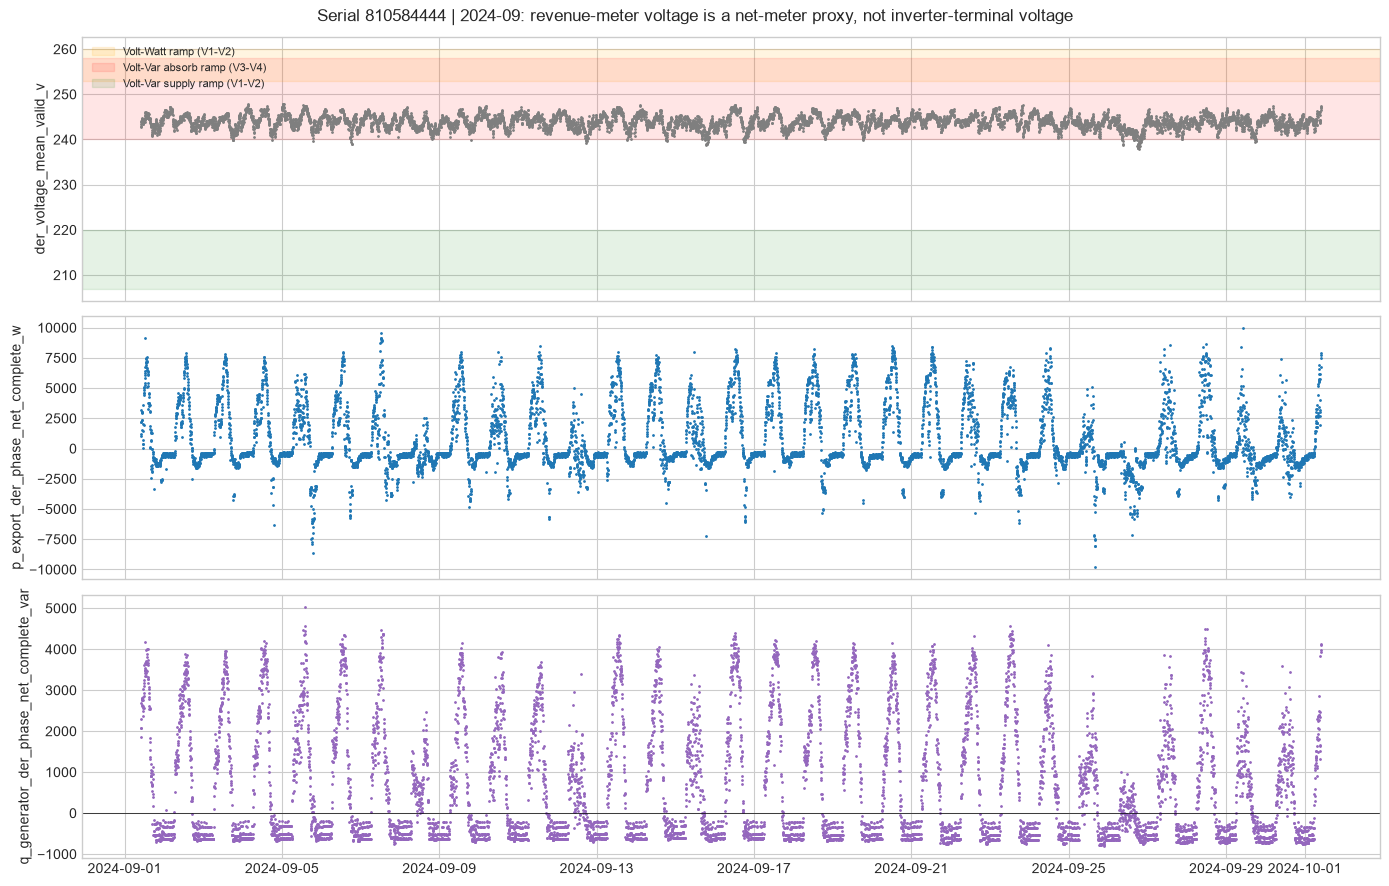

In [8]:
voltage_col = 'der_voltage_mean_valid_v' if sample['der_voltage_mean_valid_v'].notna().any() else 'voltage_mean_valid_v'
p_col = 'p_export_der_phase_net_complete_w' if sample['p_export_der_phase_net_complete_w'].notna().any() else 'p_export_net_observed_w'
q_col = 'q_generator_der_phase_net_complete_var' if sample['q_generator_der_phase_net_complete_var'].notna().any() else 'q_generator_net_observed_var'

print(f'Using voltage={voltage_col}, P={p_col}, Q={q_col}')
if p_col == 'p_export_net_observed_w':
    print('Note: DER-phase-complete P/Q were all null for this slice; falling back to whole-site net values, '
          'which include any non-DER (load-only) phases.')

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
axes[0].plot(sample.timestamp_local, sample[voltage_col], '.', ms=2, color='tab:gray')
axes[0].axhspan(AS4777['VW']['V1'], AS4777['VW']['V2'], color='orange', alpha=.12, label='Volt-Watt ramp (V1-V2)')
axes[0].axhspan(AS4777['VVAR']['V3'], AS4777['VVAR']['V4'], color='red', alpha=.10, label='Volt-Var absorb ramp (V3-V4)')
axes[0].axhspan(AS4777['VVAR']['V1'], AS4777['VVAR']['V2'], color='green', alpha=.10, label='Volt-Var supply ramp (V1-V2)')
axes[0].set_ylabel(voltage_col); axes[0].legend(fontsize=8, ncol=1, loc='upper left')

axes[1].plot(sample.timestamp_local, sample[p_col], '.', ms=2, color='tab:blue')
axes[1].set_ylabel(p_col)

axes[2].plot(sample.timestamp_local, sample[q_col], '.', ms=2, color='tab:purple')
axes[2].axhline(0, color='k', lw=.5)
axes[2].set_ylabel(q_col)

fig.suptitle(f'Serial {SERIAL} | {MONTH}: revenue-meter voltage is a net-meter proxy, not inverter-terminal voltage')
plt.tight_layout()
plt.show()

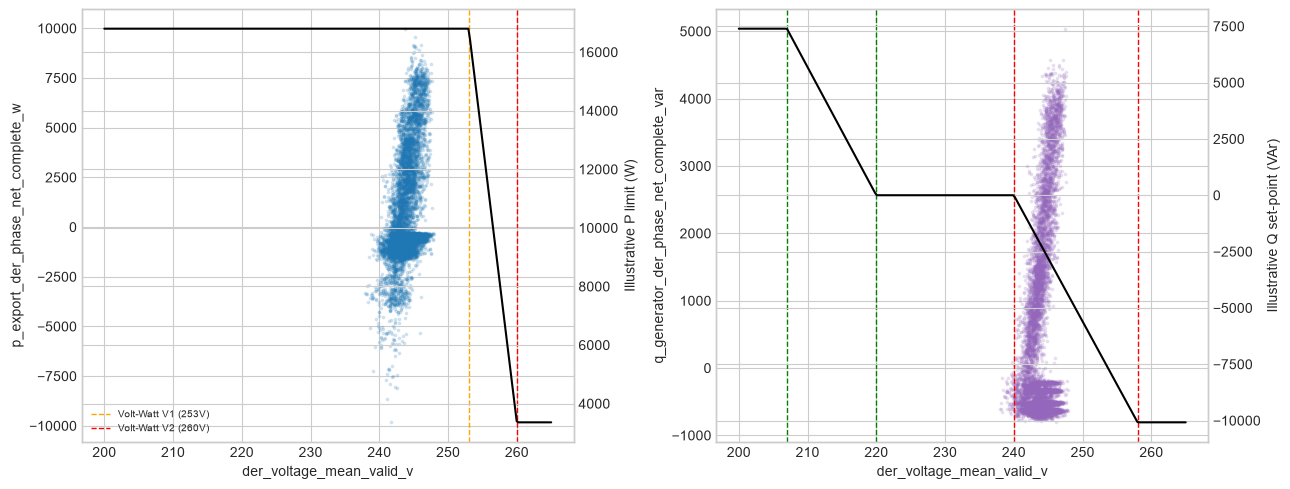

In [9]:
valid = sample[sample[voltage_col].notna() & sample[p_col].notna() & sample[q_col].notna()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(valid[voltage_col], valid[p_col], s=3, alpha=.15, color='tab:blue')
axes[0].axvline(AS4777['VW']['V1'], color='orange', ls='--', lw=1, label='Volt-Watt V1 (253V)')
axes[0].axvline(AS4777['VW']['V2'], color='red', ls='--', lw=1, label='Volt-Watt V2 (260V)')
ax0b = axes[0].twinx()
ax0b.plot(voltage_grid, vw_curve * capacity_kw * 1000, color='k', lw=1.5,
          label='AS4777 P limit (illustrative, capacity-scaled)')
ax0b.set_ylabel('Illustrative P limit (W)')
axes[0].set(xlabel=voltage_col, ylabel=p_col); axes[0].legend(fontsize=7, loc='lower left')

axes[1].scatter(valid[voltage_col], valid[q_col], s=3, alpha=.15, color='tab:purple')
for key, color in [('V1', 'green'), ('V2', 'green'), ('V3', 'red'), ('V4', 'red')]:
    axes[1].axvline(AS4777['VVAR'][key], color=color, ls='--', lw=1)
ax1b = axes[1].twinx()
ax1b.plot(voltage_grid, vvar_curve * capacity_kw * 1000, color='k', lw=1.5,
          label='AS4777 Q set-point (illustrative, capacity-scaled)')
ax1b.set_ylabel('Illustrative Q set-point (VAr)')
axes[1].set(xlabel=voltage_col, ylabel=q_col)
plt.tight_layout()
plt.show()

## Volt-Var monthly response vs AS/NZS 4777.2:2020 (Q_impact classification)

Reproduces the two-panel Q-vs-V scatter style from
`bms_sa_review/data_query/01b_fleet_eda.ipynb`, but coloured by the full
Q_impact classification from `build_conformance_voltvar.py` — not just a
simple inside/outside-tolerance-band flag. That means the band each point is
tested against is **clamped to the Figure 2.1 minimum reactive-power
capability** at the interval's measured P, so points that would look
non-conforming against the naive `+/-4%` band alone can legitimately be
`not_assessable` (P below 20% of the capacity proxy) or `conforming` (the
band widened to what Figure 2.1 actually requires at that power level). This
is expected — it's the point of respecting the capability clamp — and is why
this plot's category boundaries will not exactly match a naive tolerance-band
version.

`CAPABILITY_PROFILE = 'review_corrected'` matches `build_conformance_
voltvar.py`'s own default (does not relax the minimum-capability requirement
above 80% of the capacity proxy). Set it to `'hossein_m3'` to compare against
the legacy profile, which does relax above 80% and treats every interval as
assessable.

Out of scope here (see `voltvar_voltwatt_lib.py`'s docstring): the `S_99` /
counterfactual-based Method A curtailment-energy estimate. Only the
required-Q classification is reproduced.

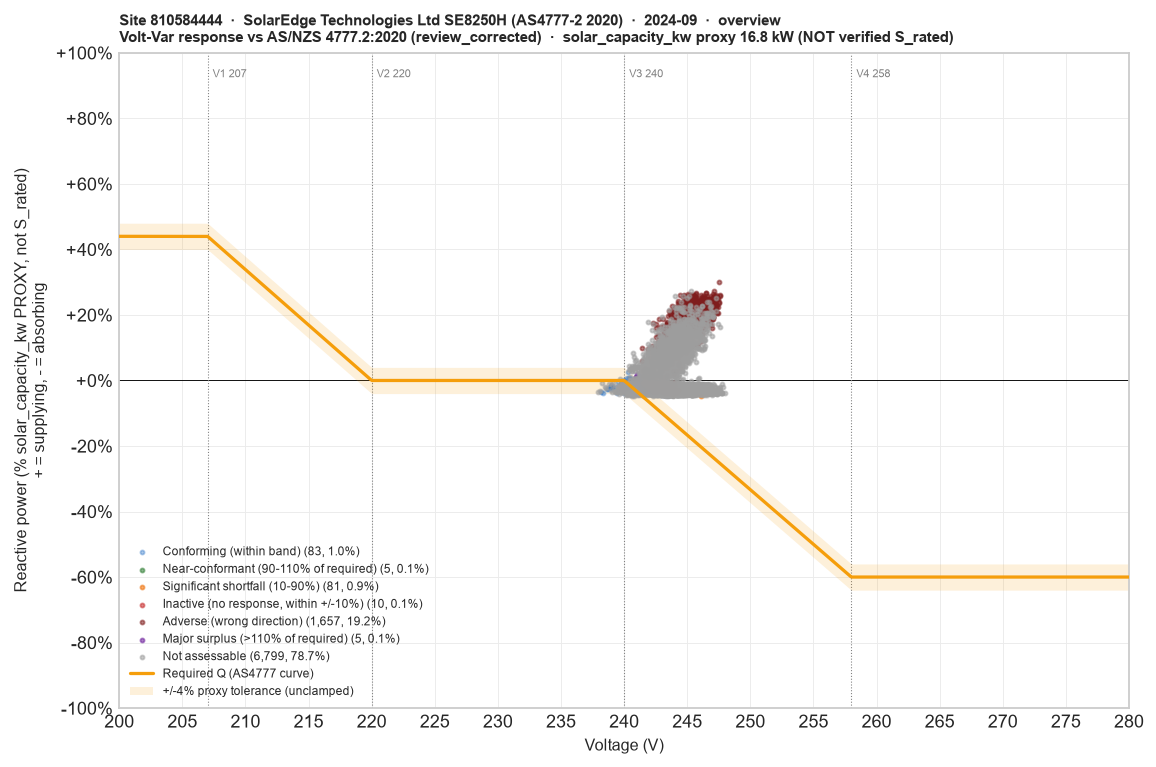

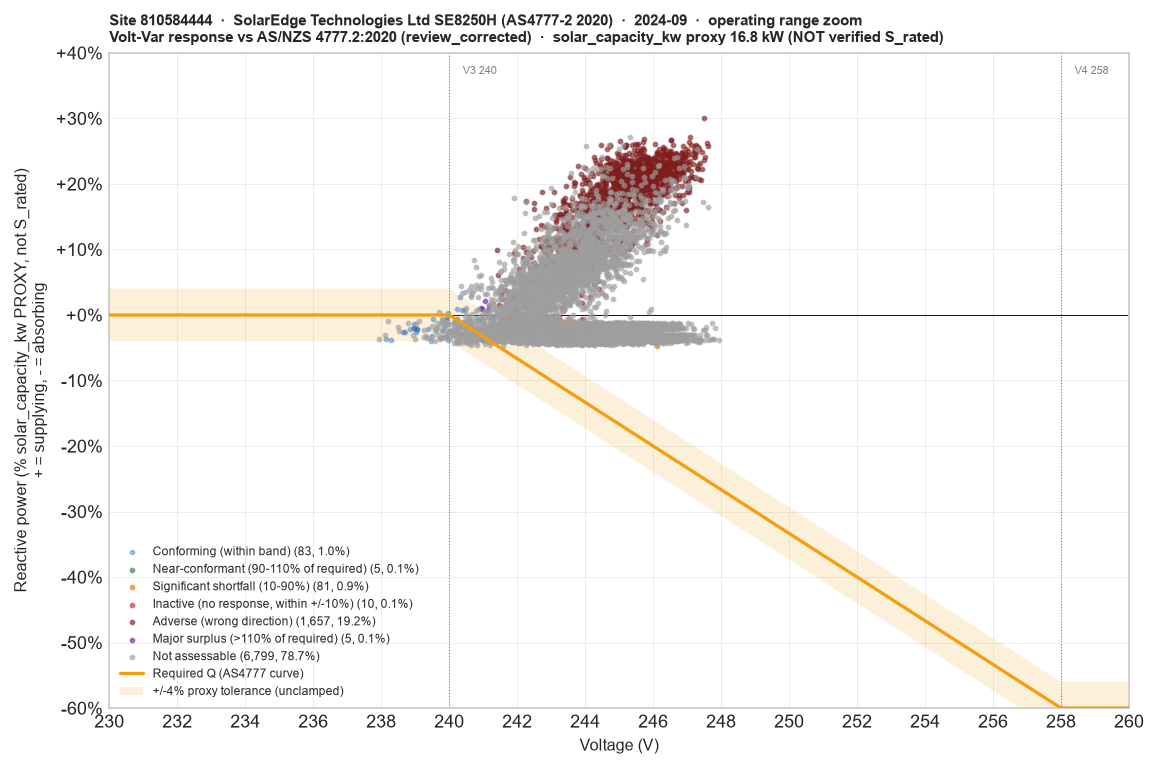

Status breakdown (8,640 intervals total):
  conforming                      83  (  1.0%)
  Q_near_conformant                5  (  0.1%)
  Q_significant_shortfall         81  (  0.9%)
  Q_inactive                      10  (  0.1%)
  Q_adverse                    1,657  ( 19.2%)
  Q_major_surplus                  5  (  0.1%)
  not_assessable               6,799  ( 78.7%)


In [10]:
CAPABILITY_PROFILE = 'review_corrected'  # or 'hossein_m3'

scatter_df = pd.DataFrame({
    'V': sample[voltage_col],
    'P_kW': sample[p_col] / 1000.0,
    'Q_kvar': sample[q_col] / 1000.0,
})

classified = plot_vvar_month_scatter_ausgrid(
    scatter_df, SERIAL, capacity_kw, MONTH,
    capability_profile=CAPABILITY_PROFILE, manufacturer=manufacturer,
)

## Pick a day for the operational-modes plot

Ranks days by how many intervals crossed the Volt-Var deadband-high
threshold (`V3`, 240 V) — the same idea as
`bms_sa_review/data_query/lib/site_selection.py::suggest_days`. Pick any date
from `sample['local_date']` instead if you'd rather look at a specific day
regardless of exposure.

In [11]:
V_THRESHOLD = AS4777['VVAR']['V3']
hits = (sample[sample[voltage_col] > V_THRESHOLD]
        .groupby('local_date')[voltage_col]
        .count().sort_values(ascending=False))

if hits.empty:
    print(f'No days with {voltage_col} > {V_THRESHOLD} V. Pick any date from sample.local_date.unique().')
else:
    print(f'Days with {voltage_col} > {V_THRESHOLD} V (most first):')
    display(hits.head(15))
    print('Best candidate:', hits.index[0], f'({hits.iloc[0]} intervals)')

Days with der_voltage_mean_valid_v > 240.0 V (most first):


local_date
2024-09-02    288
2024-09-07    288
2024-09-08    288
2024-09-10    288
2024-09-11    288
2024-09-28    288
2024-09-30    288
2024-09-24    288
2024-09-25    288
2024-09-23    288
2024-09-22    288
2024-09-20    288
2024-09-21    288
2024-09-18    288
2024-09-17    288
Name: der_voltage_mean_valid_v, dtype: int64

Best candidate: 2024-09-02 00:00:00 (288 intervals)


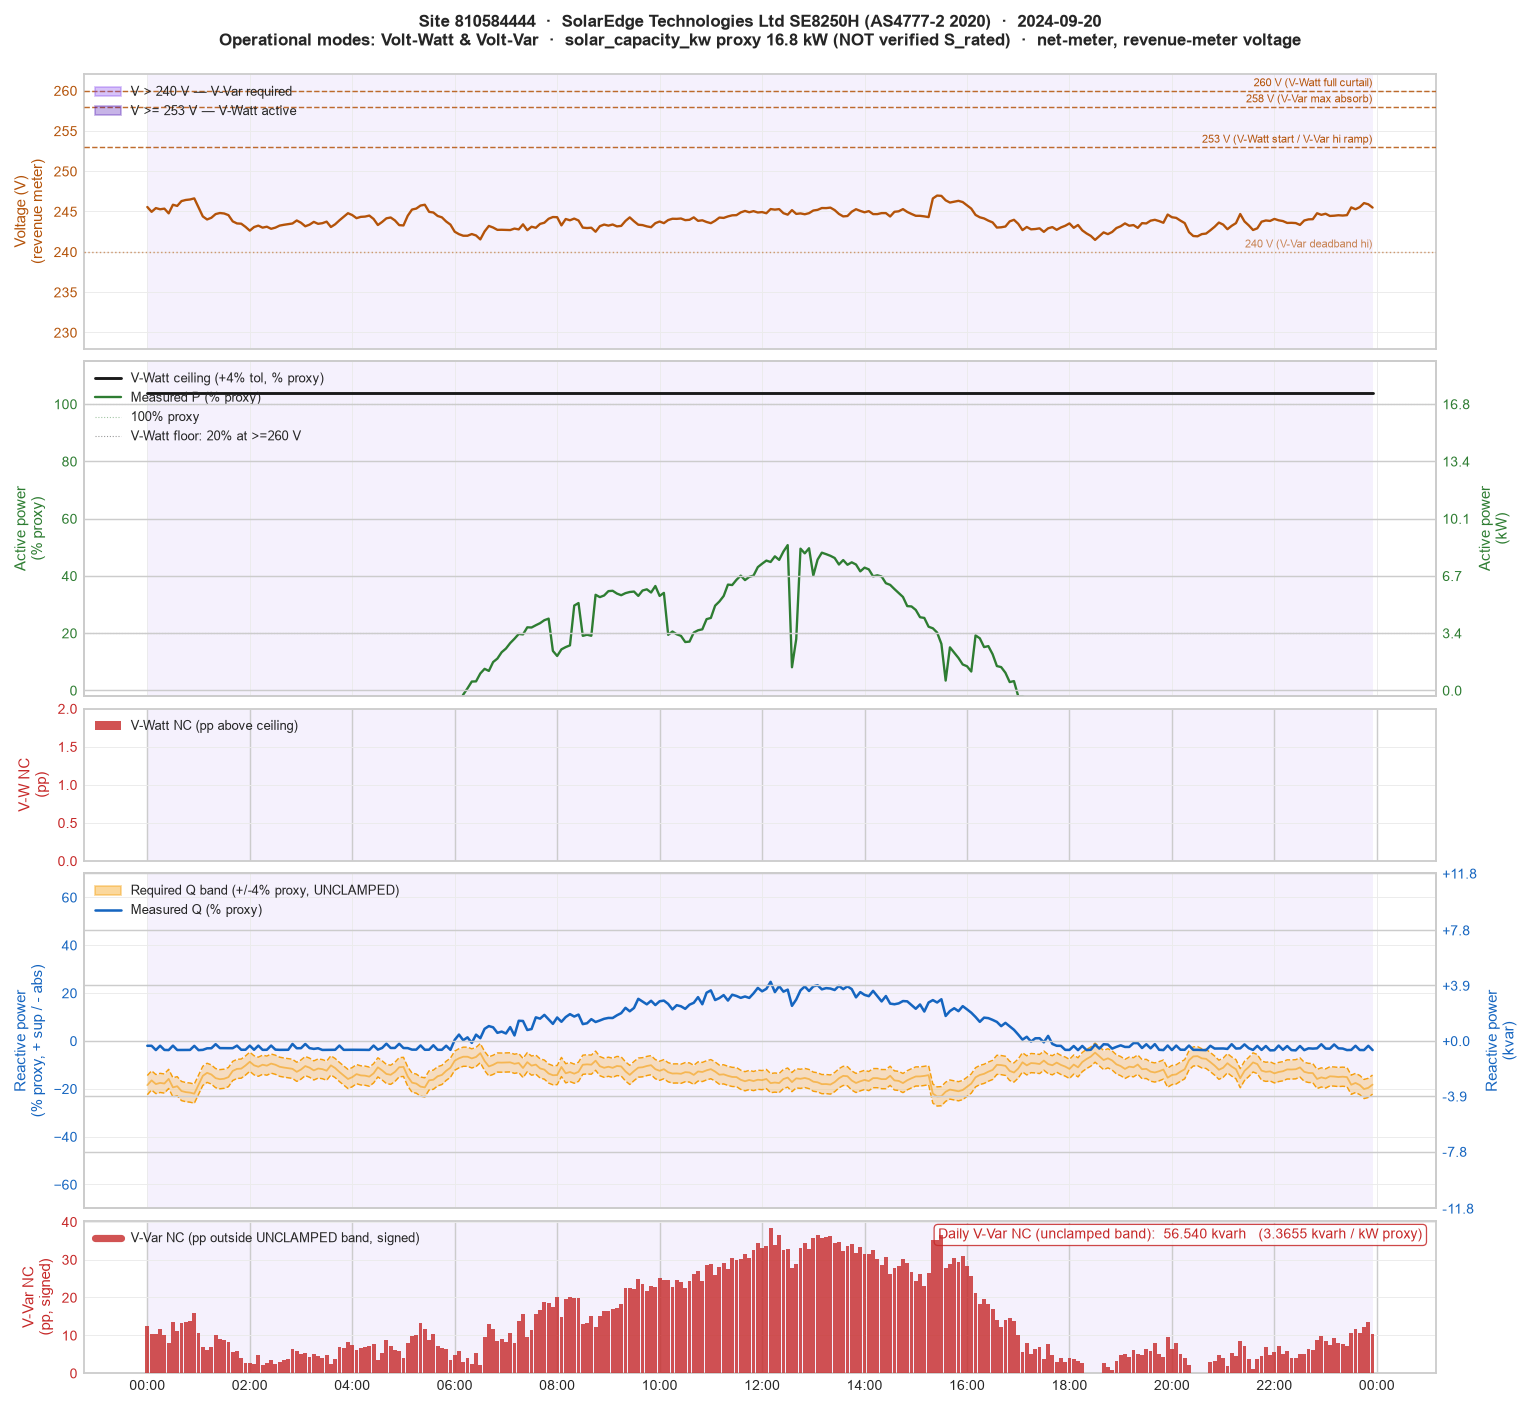


Volt-Watt:  0 intervals above the unclamped ceiling
Volt-Var:   280 intervals outside the unclamped band  |  56.540 kvarh  (3.3655 kvarh/kW proxy)


In [12]:
ZOOM_DATE = str(pd.Timestamp(hits.index[0]).date()) if len(hits) else str(pd.Timestamp(sample['local_date'].iloc[0]).date())
# ZOOM_DATE = '2025-04-15'  # override with any date from sample['local_date']
ZOOM_DATE = '2024-09-20'

# .dt.date normalises both sides to plain dates before comparing -- local_date
# comes back from DuckDB as datetime64[ns] at midnight, and comparing that
# directly to a bare datetime.date silently matches nothing.
df_day = sample[sample['local_date'].dt.date == pd.Timestamp(ZOOM_DATE).date()].copy()
assert len(df_day) > 0, f'No rows for {ZOOM_DATE}. Pick a date from sample["local_date"].unique().'
df_day['voltage'] = df_day[voltage_col]
df_day['P_kW'] = df_day[p_col] / 1000.0
df_day['Q_kvar'] = df_day[q_col] / 1000.0

plot_operational_ausgrid(df_day, SERIAL, capacity_kw, ZOOM_DATE, manufacturer=manufacturer)

## Original / raw-most signals for this site

Everything above reads `structured_telemetry/*` (Delivery 2). That's already
been through: timezone/duplicate canonicalisation (Delivery 1), the working
sign-convention multiply (`active_export_sign`, `reactive_absorbing_sign`),
and site/phase aggregation. None of that is visible from the plots above --
you're seeing the *result* of those steps, not the values Ausgrid actually
supplied.

**Data lineage, rawest to most processed:**

1. Raw ZIPs/CSVs as supplied by Ausgrid, directly under
   `CICCADA - Data/Ausgrid/` (not `derived/`). Not read anywhere in this
   notebook, and not currently in a folder this notebook has access to.
2. `ausgrid_pv_combined.parquet` (the `telemetry_parquet` path in
   `analysis.toml`) -- a straight concatenation of those CSVs into parquet.
   Also outside `derived/`, also not read here. This is the true "raw-most"
   table if you want to rule out anything upstream of Delivery 1 -- say so
   and I'll ask for access to that folder.
3. **`derived/canonical_phase/` (Delivery 1 output)** -- what the cell below
   reads. It deduplicates and splits UTC/local timestamps, but its
   `active_power_raw_w` and `reactive_power_raw_var` columns are, per
   `DATA_CONTRACT.md`, the **unchanged provider value** -- the same numbers
   as in the CSV, just typed and timestamped. `p_export_w` /
   `q_absorbing_var` / `q_generator_var` sit alongside them in the same
   table as the *first* (and only) sign transform applied -- no phase
   mapping, no DER inference, no aggregation. This is the practical
   "original data" layer: as close to the provider's numbers as you can get
   without re-parsing the source CSVs yourself.
4. `derived/structured_telemetry/*` (Delivery 2) -- phase mapping, DER
   inference, site/phase aggregation. Everything above this cell in the
   notebook.

**The plot below** pulls `canonical_phase` for `SERIAL` on `ZOOM_DATE` and
shows:

- Voltage, each phase (raw `voltage_v`)
- Voltage, averaged across phases
- Active power, each phase -- **raw, untouched** (`active_power_raw_w`)
- Reactive power, each phase -- **raw, untouched** (`reactive_power_raw_var`)
- Total active power, all phases (sum of `p_export_w`, sign-corrected so
  `+` = export -- summing the raw values directly would mix an arbitrary
  provider sign convention across phases and not mean anything physically)
- Total reactive power, all phases (sum of `q_absorbing_var`, `+` =
  absorbing) -- added as the "something else" panel, pairing with the P
  total and directly relevant to the `Q_adverse` question driving this
  section

**One wrinkle you may hit:** on a DST-transition day (e.g. the first Sunday
in April, NSW fall-back), local civil time repeats an hour, so
`timestamp_local` is not a unique key for that date at phase level. The cell
below pivots on `timestamp_utc` instead so no rows get silently dropped.

The two "raw, untouched" panels are the ones that answer "what signals are
actually being used" -- if something looks wrong there, it's in the data
Ausgrid supplied, not in this pipeline's processing.

canonical_phase source: C:\Users\z3553082\OneDrive - UNSW\Documents\CICCADA - Data\Ausgrid\derived\canonical_phase


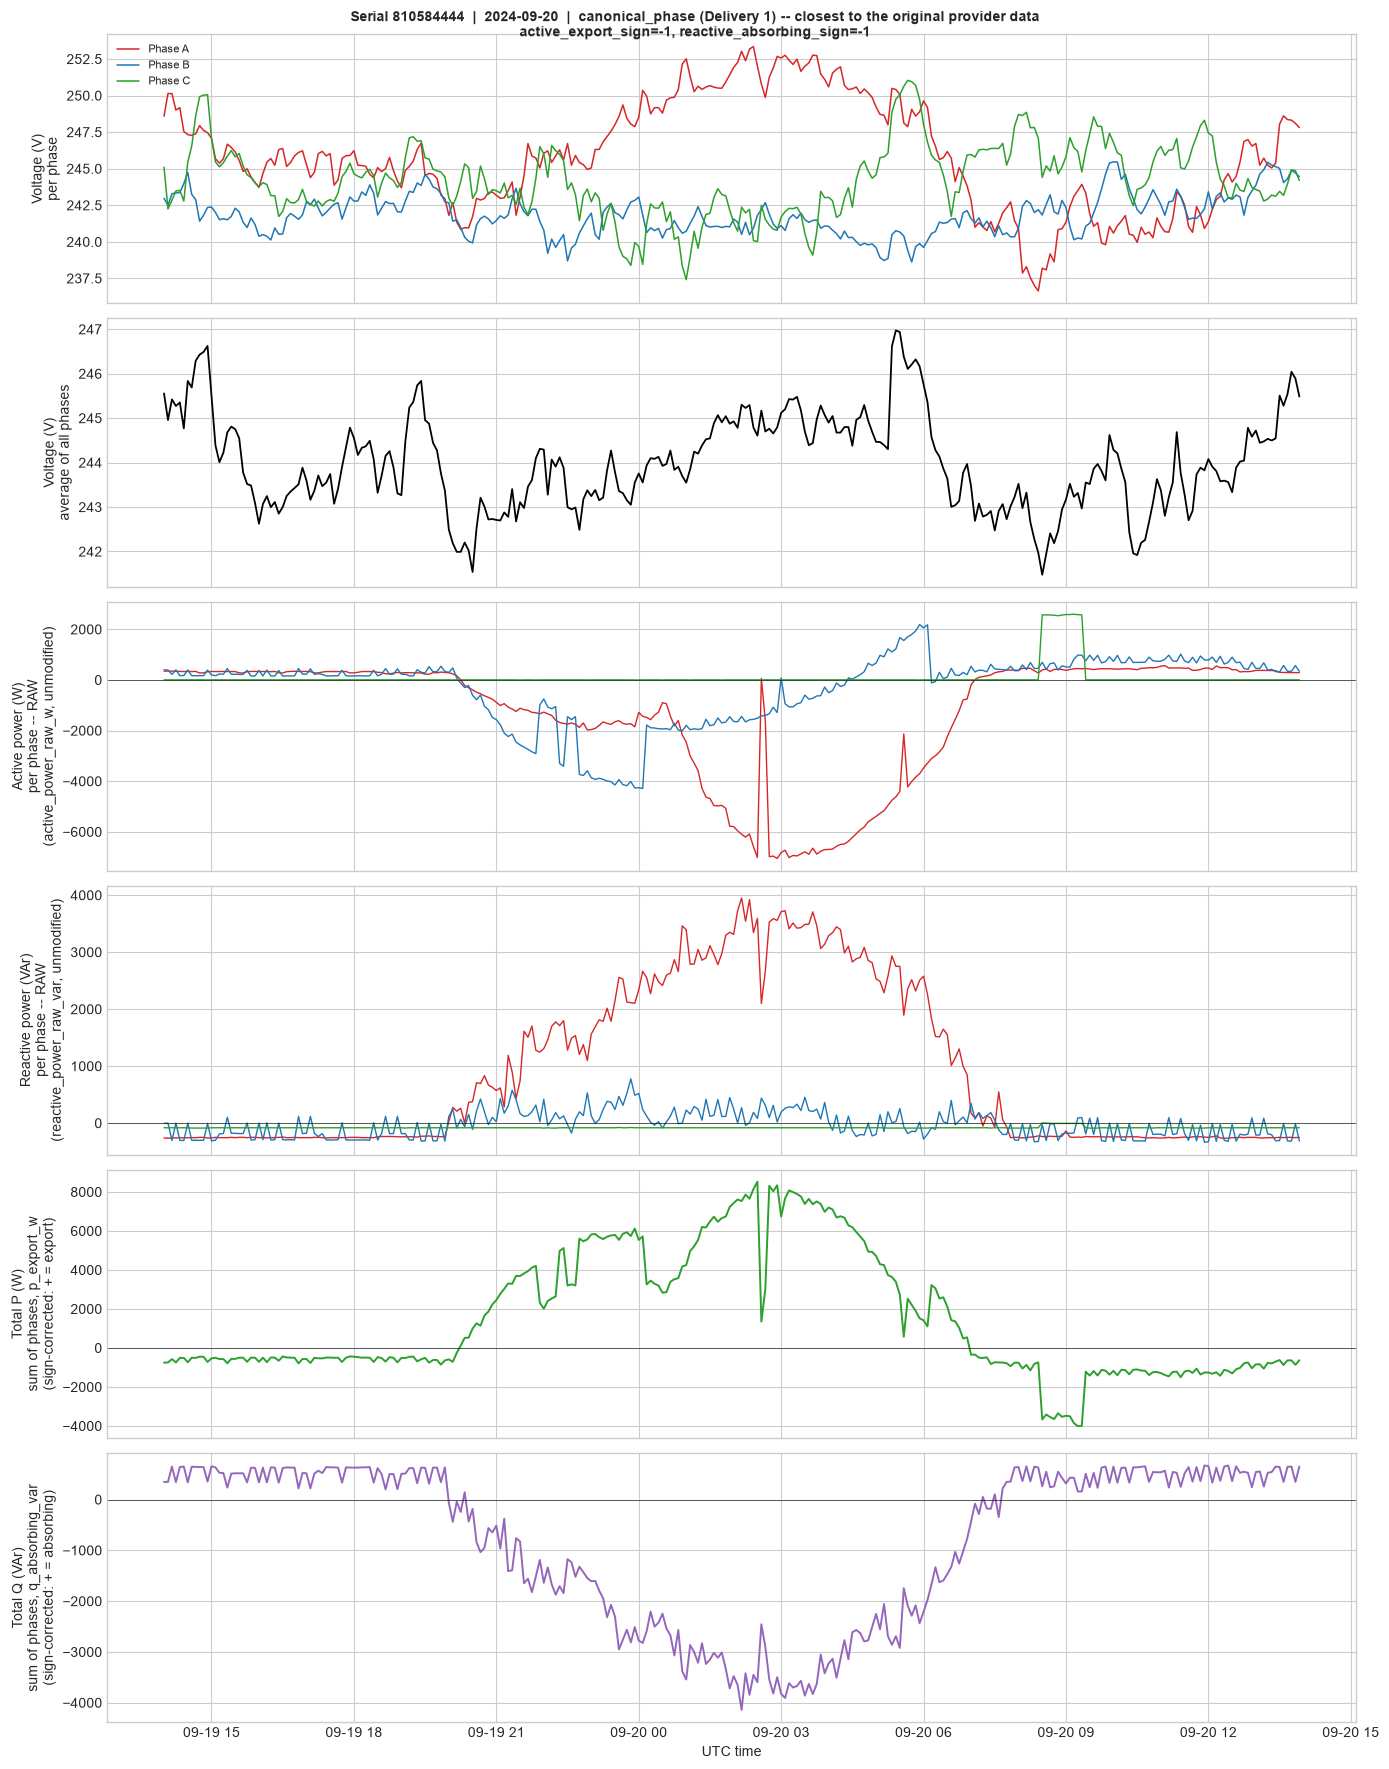

,serial,timestamp_utc,timestamp_local,phase,voltage_v,current_a,active_power_raw_w,reactive_power_raw_var,p_export_w,q_absorbing_var,q_generator_var,source_month,source_file,duplicate_count,duplicate_source_file_count,duplicate_status,row_has_null_measurement,voltage_physical_ok,metadata_available,analysis_cohort,install_phase_count,month_utc,site_bucket,year_utc
0,810584444,2024-09-19 14:00:00+00:00,2024-09-20 00:00:00,A,248.585000,1.915998,347.153442,-260.365082,-347.153442,260.365082,-260.365082,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024
1,810584444,2024-09-19 14:00:00+00:00,2024-09-20 00:00:00,B,242.978210,1.772393,403.310638,-5.105198,-403.310638,5.105198,-5.105198,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024
2,810584444,2024-09-19 14:00:00+00:00,2024-09-20 00:00:00,C,245.101379,0.340118,5.105198,-81.683170,-5.105198,81.683170,-81.683170,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024
3,810584444,2024-09-19 14:05:00+00:00,2024-09-20 00:05:00,A,250.141312,1.927335,352.258667,-265.470276,-352.258667,265.470276,-265.470276,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024
4,810584444,2024-09-19 14:05:00+00:00,2024-09-20 00:05:00,B,242.483500,1.708148,387.995056,0.000000,-387.995056,-0.000000,0.000000,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024
5,810584444,2024-09-19 14:05:00+00:00,2024-09-20 00:05:00,C,242.246445,0.336339,5.105198,-81.683170,-5.105198,81.683170,-81.683170,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024
6,810584444,2024-09-19 14:10:00+00:00,2024-09-20 00:10:00,A,250.131000,1.908440,347.153442,-260.365082,-347.153442,260.365082,-260.365082,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024
7,810584444,2024-09-19 14:10:00+00:00,2024-09-20 00:10:00,B,243.287415,1.749718,219.523514,-306.311900,-219.523514,306.311900,-306.311900,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024
8,810584444,2024-09-19 14:10:00+00:00,2024-09-20 00:10:00,C,242.844223,0.336339,5.105198,-81.683170,-5.105198,81.683170,-81.683170,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024
9,810584444,2024-09-19 14:15:00+00:00,2024-09-20 00:15:00,A,249.007584,1.874428,342.048248,-260.365082,-342.048248,260.365082,-260.365082,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,27,2024


In [13]:
from ausgrid_analysis.db import canonical_output_path

canonical_dir = canonical_output_path(config, full_scope)
assert canonical_dir.is_dir(), f'Run notebook 01 first: {canonical_dir}'
# Scoped to year/month (not a fully-recursive glob): canonical_phase is far more
# finely partitioned than structured_telemetry (many small files per bucket), so
# a `**` glob across every year/month is slow. Scoping to the known year/month
# keeps this fast while still using hive-partition pruning for site_bucket.
canonical_glob = str(canonical_dir / f'year_utc={year}' / f'month_utc={month}' / '**' / '*.parquet')
con.execute(
    f"CREATE VIEW IF NOT EXISTS canonical AS "
    f"SELECT * FROM read_parquet({sql_string(canonical_glob)}, hive_partitioning=true)"
)
print('canonical_phase source:', canonical_dir)

raw_where = ['serial=?', f'site_bucket = mod(hash(?), {bucket_count})', 'cast(timestamp_local as date) = ?']
raw_params = [str(SERIAL), str(SERIAL), ZOOM_DATE]
raw_query = f'''SELECT * FROM canonical WHERE {" AND ".join(raw_where)} ORDER BY timestamp_utc, phase'''
raw_day = con.execute(raw_query, raw_params).fetchdf()
assert len(raw_day) > 0, f'No canonical_phase rows for serial {SERIAL} on {ZOOM_DATE}.'

# Pivot on timestamp_utc, not timestamp_local: local civil time is not a unique
# key on a DST-transition day (e.g. 2025-04-06, NSW fall-back -- the repeated
# local hour collides). UTC is always unique regardless of which ZOOM_DATE is
# picked.
dupe_local = raw_day.groupby(['timestamp_local', 'phase']).size()
if (dupe_local > 1).any():
    print(f'Note: {ZOOM_DATE} has repeated local timestamps (DST transition) -- '
          'plotting against timestamp_utc to keep every row.')

wide_v = raw_day.pivot(index='timestamp_utc', columns='phase', values='voltage_v').sort_index()
wide_p_raw = raw_day.pivot(index='timestamp_utc', columns='phase', values='active_power_raw_w').sort_index()
wide_q_raw = raw_day.pivot(index='timestamp_utc', columns='phase', values='reactive_power_raw_var').sort_index()
wide_p_export = raw_day.pivot(index='timestamp_utc', columns='phase', values='p_export_w').sort_index()
wide_q_absorb = raw_day.pivot(index='timestamp_utc', columns='phase', values='q_absorbing_var').sort_index()

phase_colors = {'A': 'tab:red', 'B': 'tab:blue', 'C': 'tab:green'}
fig, axes = plt.subplots(6, 1, figsize=(14, 18), sharex=True)

for ph in wide_v.columns:
    axes[0].plot(wide_v.index, wide_v[ph], color=phase_colors.get(ph, 'grey'), lw=1.1, label=f'Phase {ph}')
axes[0].set_ylabel('Voltage (V)\nper phase'); axes[0].legend(fontsize=8, loc='upper left')

axes[1].plot(wide_v.index, wide_v.mean(axis=1), color='black', lw=1.3)
axes[1].set_ylabel('Voltage (V)\naverage of all phases')

for ph in wide_p_raw.columns:
    axes[2].plot(wide_p_raw.index, wide_p_raw[ph], color=phase_colors.get(ph, 'grey'), lw=1.0)
axes[2].axhline(0, color='k', lw=.4)
axes[2].set_ylabel('Active power (W)\nper phase -- RAW\n(active_power_raw_w, unmodified)')

for ph in wide_q_raw.columns:
    axes[3].plot(wide_q_raw.index, wide_q_raw[ph], color=phase_colors.get(ph, 'grey'), lw=1.0)
axes[3].axhline(0, color='k', lw=.4)
axes[3].set_ylabel('Reactive power (VAr)\nper phase -- RAW\n(reactive_power_raw_var, unmodified)')

axes[4].plot(wide_p_export.index, wide_p_export.sum(axis=1), color='tab:green', lw=1.4)
axes[4].axhline(0, color='k', lw=.4)
axes[4].set_ylabel('Total P (W)\nsum of phases, p_export_w\n(sign-corrected: + = export)')

axes[5].plot(wide_q_absorb.index, wide_q_absorb.sum(axis=1), color='tab:purple', lw=1.4)
axes[5].axhline(0, color='k', lw=.4)
axes[5].set_ylabel('Total Q (VAr)\nsum of phases, q_absorbing_var\n(sign-corrected: + = absorbing)')
axes[5].set_xlabel('UTC time')

fig.suptitle(
    f'Serial {SERIAL}  |  {ZOOM_DATE}  |  canonical_phase (Delivery 1) -- closest to the original provider data\n'
    f'active_export_sign={config.assumptions.active_export_sign}, '
    f'reactive_absorbing_sign={config.assumptions.reactive_absorbing_sign}',
    fontsize=10, fontweight='bold',
)
plt.tight_layout()
plt.show()

display(raw_day.head(10))

## Sign trace and per-phase DER identification

Two separate checks, prompted by the `Q_adverse` result above:

1. **Is the raw-to-derived sign hypothesis wrong?** `q_absorbing_var` is
   computed as `reactive_power_raw_var * reactive_absorbing_sign`, with
   `reactive_absorbing_sign = -1` set in `analysis.toml` as a *working
   hypothesis*, unverified per `METHODOLOGY_GATES.md` gate 3. Below prints
   and plots `reactive_power_raw_var` (untouched provider value) next to the
   derived `q_absorbing_var`, per phase, so you can eyeball whether the sign
   of the raw provider field itself lines up with what "absorbing" should
   look like physically -- independent of any convention bookkeeping this
   notebook has done on top of it.

2. **Is the phase-to-DER mapping wrong?** The site-level `Q_adverse` result
   sums only the phases `site_profile.inferred_der_phases` marks as
   DER-connected. If that inference is wrong for this site, summing the
   wrong phase(s) could produce an "adverse"-looking signal that has nothing
   to do with the actual inverter's response. Below plots voltage, active
   power and reactive power for each phase separately, tagged with whether
   the pipeline inferred it as a DER phase, so a load-only phase masquerading
   as DER (or vice versa) would be visible directly.

For serial `810584444` specifically, `site_profile` already reports
`inferred_der_phases = A|B|C`, `phase_mapping_method =
all_power_available_phases`, `phase_mapping_confidence = high` -- i.e. all
three phases carry power measurements and were all assigned to the inverter,
so there's no single hidden DER phase to find for *this* site. The per-phase
view is still useful here as a consistency check (do all three phases behave
the same way?), and becomes the primary diagnostic for sites where only one
or two phases are inferred as DER.

In [14]:
structured_phase_dir = structured_phase_output_path(config, full_scope)
assert structured_phase_dir.is_dir(), f'Run notebook 02b first: {structured_phase_dir}'
structured_phase_glob = str(structured_phase_dir / '**' / '*.parquet')
con.execute(
    f"CREATE VIEW IF NOT EXISTS phase_intervals AS "
    f"SELECT * FROM read_parquet({sql_string(structured_phase_glob)}, hive_partitioning=true)"
)
print('structured_phase_intervals source:', structured_phase_dir)

phase_where = ['year_utc=?', 'month_utc=?', 'serial=?', f'site_bucket = mod(hash(?), {bucket_count})']
phase_params = [year, month, str(SERIAL), str(SERIAL)]
phase_query = f'''SELECT * FROM phase_intervals WHERE {" AND ".join(phase_where)} ORDER BY timestamp_utc, phase LIMIT ?'''
phase_sample = con.execute(phase_query, [*phase_params, MAX_ROWS * 3]).fetchdf()
assert len(phase_sample) > 0, 'No phase-level rows for this serial/month.'

# Sanity check: the pipeline's own persisted q_generator_var should be an
# exact negation of q_absorbing_var. If this is not ~0, something upstream
# of this notebook is inconsistent, not just this notebook's own bookkeeping.
consistency = (phase_sample['q_generator_var'] - (-phase_sample['q_absorbing_var'])).abs().max()
print(f'\nMax |q_generator_var - (-q_absorbing_var)| = {consistency:.9f}  (should be ~0)')

print(f'\nreactive_absorbing_sign in use: {config.assumptions.reactive_absorbing_sign} '
      f'(q_absorbing_var = reactive_power_raw_var * {config.assumptions.reactive_absorbing_sign})')

print(f'\nRaw vs derived reactive power, by phase, {MONTH} (whole month):')
display(
    phase_sample.groupby('phase')[['reactive_power_raw_var', 'q_absorbing_var', 'q_generator_var']]
    .agg(['count', 'mean', 'min', 'max'])
)

print('\nis_inferred_der_phase by phase:')
display(phase_sample.groupby('phase')['is_inferred_der_phase'].first())

structured_phase_intervals source: C:\Users\z3553082\OneDrive - UNSW\Documents\CICCADA - Data\Ausgrid\derived\structured_telemetry\structured_phase_intervals

Max |q_generator_var - (-q_absorbing_var)| = 0.000000000  (should be ~0)

reactive_absorbing_sign in use: -1 (q_absorbing_var = reactive_power_raw_var * -1)

Raw vs derived reactive power, by phase, 2024-09 (whole month):


reactive_power_raw_var                                       \
                       count        mean         min          max   
phase                                                               
A                       8640  741.503998 -316.522278  4400.680660   
B                       8640  -50.810310 -576.887400  1118.038330   
C                       8640  -72.772707  -86.788360   622.834167   

      q_absorbing_var                                      q_generator_var  \
                count        mean          min         max           count   
phase                                                                        
A                8640 -741.503998 -4400.680660  316.522278            8640   
B                8640   50.810310 -1118.038330  576.887400            8640   
C                8640   72.772707  -622.834167   86.788360            8640   

                                            
             mean         min          max  
phase                                       
A      741.503998 -316.522278  4400.680660  
B      -50.810310 -576.887400  1118.038330  
C      -72.772707  -86.788360   622.834167


is_inferred_der_phase by phase:


phase
A    True
B    True
C    True
Name: is_inferred_der_phase, dtype: bool

Phases inferred as DER-connected: {'B', 'A', 'C'}


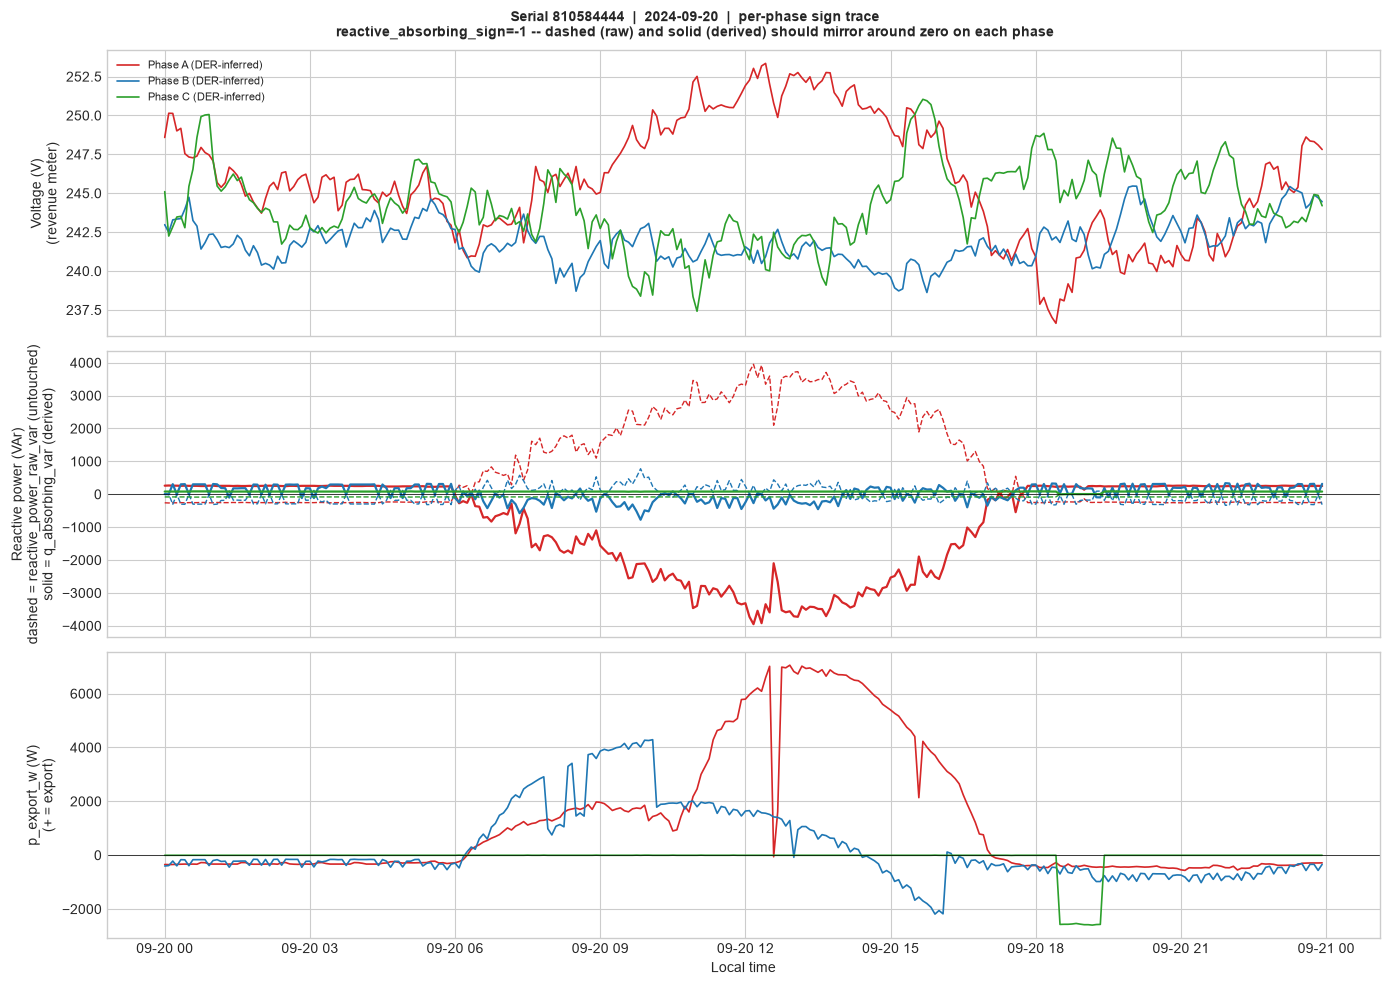

In [15]:
profile = con.execute('SELECT * FROM site_profile WHERE serial = ?', [str(SERIAL)]).fetchdf()
der_phases = set(str(profile['inferred_der_phases'].iloc[0]).split('|')) if len(profile) and pd.notna(profile['inferred_der_phases'].iloc[0]) else set()
print('Phases inferred as DER-connected:', der_phases or '(none / not assessable)')

day_phase = phase_sample[phase_sample['local_date'].dt.date == pd.Timestamp(ZOOM_DATE).date()].copy()
assert len(day_phase) > 0, f'No phase-level rows for {ZOOM_DATE}.'

phase_colors = {'A': 'tab:red', 'B': 'tab:blue', 'C': 'tab:green'}
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for ph, g in day_phase.groupby('phase'):
    g = g.sort_values('timestamp_local')
    color = phase_colors.get(ph, 'grey')
    tag = 'DER-inferred' if ph in der_phases else 'NOT DER-inferred'
    axes[0].plot(g['timestamp_local'], g['voltage_v'], color=color, lw=1.2, label=f'Phase {ph} ({tag})')
    axes[1].plot(g['timestamp_local'], g['reactive_power_raw_var'], color=color, lw=1.0, ls='--')
    axes[1].plot(g['timestamp_local'], g['q_absorbing_var'], color=color, lw=1.6)
    axes[2].plot(g['timestamp_local'], g['p_export_w'], color=color, lw=1.2)

axes[0].set_ylabel('Voltage (V)\n(revenue meter)')
axes[0].legend(fontsize=8, loc='upper left')
axes[1].axhline(0, color='k', lw=.5)
axes[1].set_ylabel('Reactive power (VAr)\ndashed = reactive_power_raw_var (untouched)\nsolid = q_absorbing_var (derived)')
axes[2].axhline(0, color='k', lw=.5)
axes[2].set_ylabel('p_export_w (W)\n(+ = export)')
axes[2].set_xlabel('Local time')
fig.suptitle(
    f'Serial {SERIAL}  |  {ZOOM_DATE}  |  per-phase sign trace\n'
    f'reactive_absorbing_sign={config.assumptions.reactive_absorbing_sign} -- '
    'dashed (raw) and solid (derived) should mirror around zero on each phase',
    fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

### Per-phase Volt-Var response (diagnostic)

Reuses `plot_vvar_month_scatter_ausgrid` per phase, plus the combined
DER-net view again for direct comparison. **The capacity proxy is split
evenly across the number of DER-inferred phases** (`capacity_kw / N`) as an
approximation for a single-phase share of a multi-phase inverter's rating --
AS/NZS 4777.2 conformance is fundamentally an inverter-level (all phases
combined) question, so treat the per-phase panels as a diagnostic for
consistency and phase-mapping sanity, not as N independent conformance
results. The **combined** panel (last) is the one worth trusting for an
actual inverter-level read, and is identical to the one earlier in this
notebook.

This produces `2 x (N_phases + 1)` figures -- expect several plots below.

Splitting 16.799999237060547 kW across 3 DER-inferred phase(s) -> 5.60 kW/phase for the per-phase panels below.

=== Phase A (DER-inferred) ===


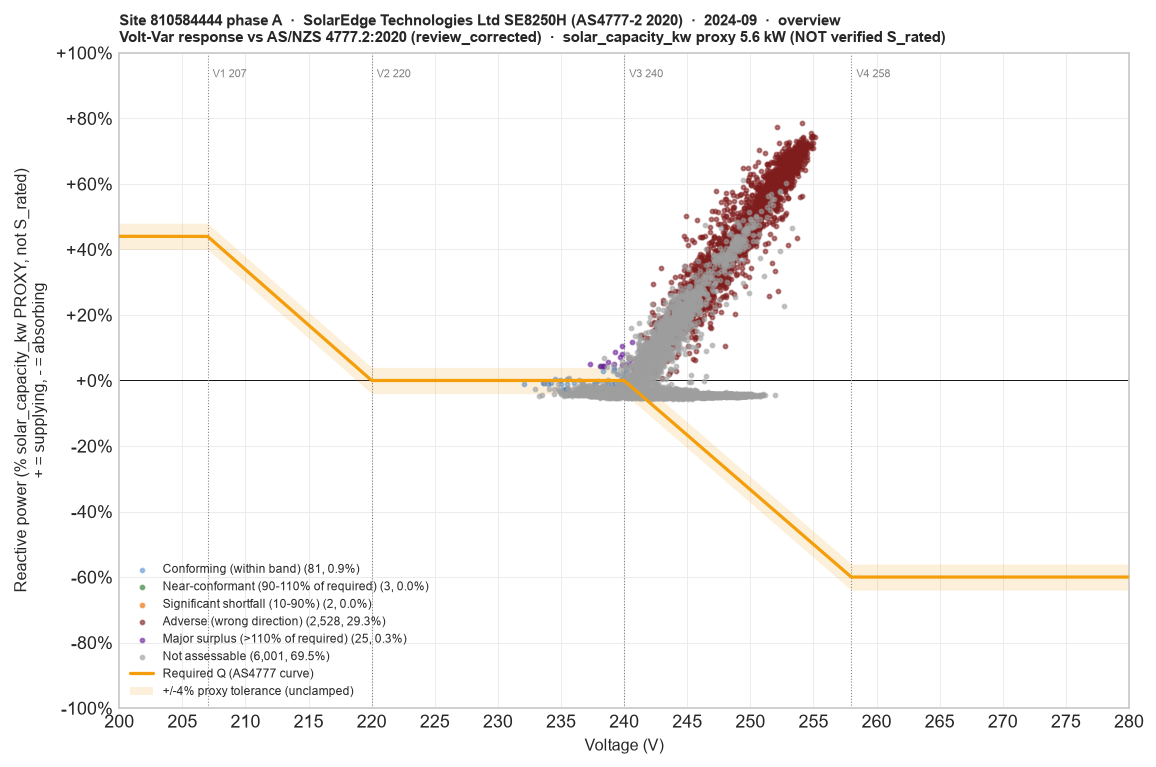

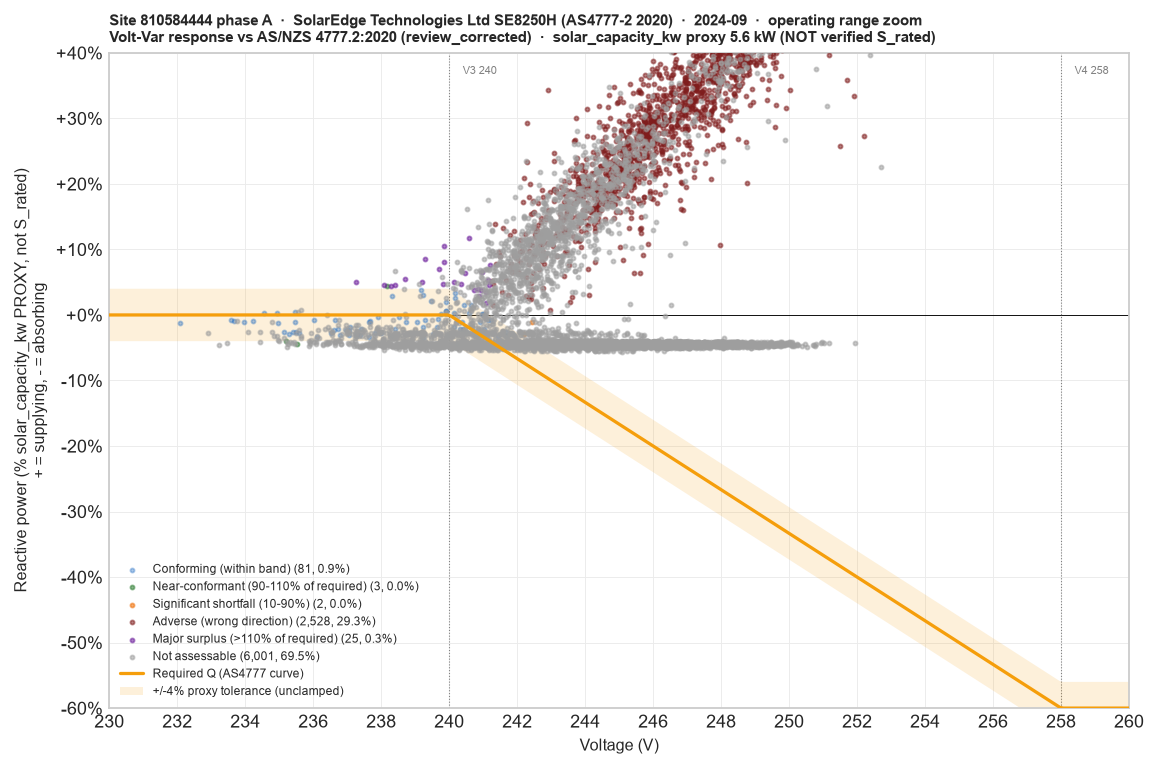

Status breakdown (8,640 intervals total):
  conforming                      81  (  0.9%)
  Q_near_conformant                3  (  0.0%)
  Q_significant_shortfall          2  (  0.0%)
  Q_inactive                       0  (  0.0%)
  Q_adverse                    2,528  ( 29.3%)
  Q_major_surplus                 25  (  0.3%)
  not_assessable               6,001  ( 69.5%)

=== Phase B (DER-inferred) ===


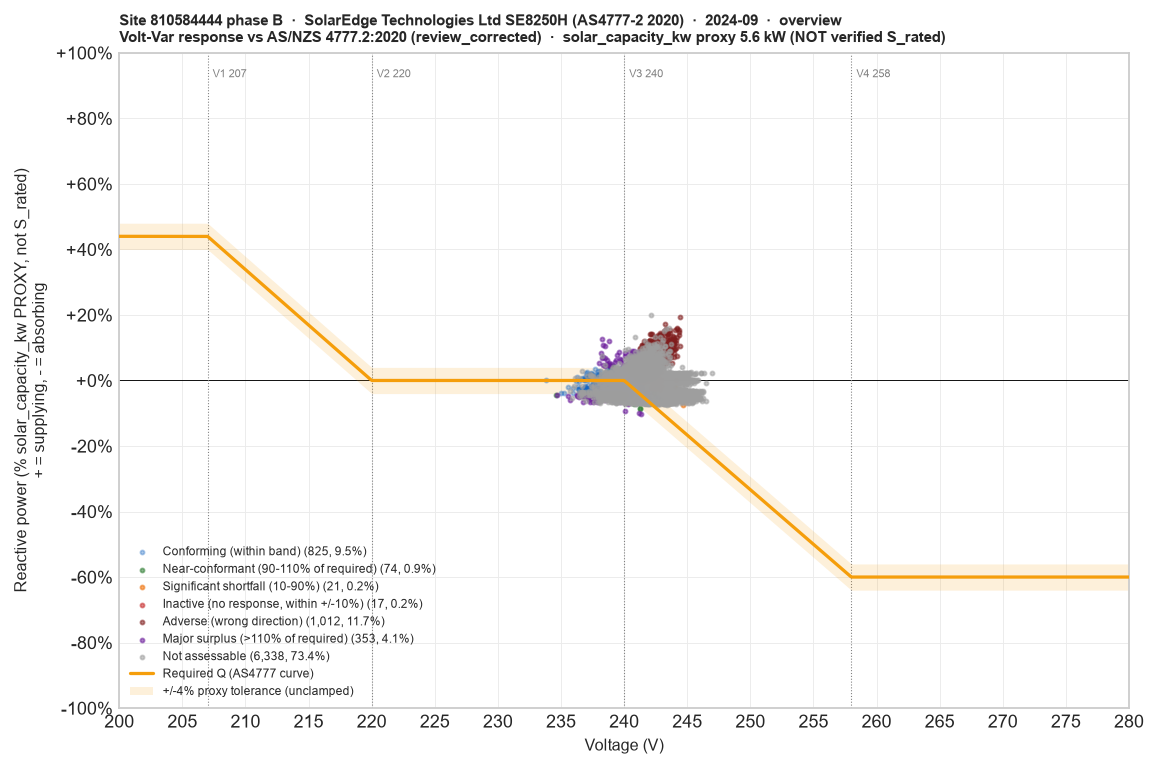

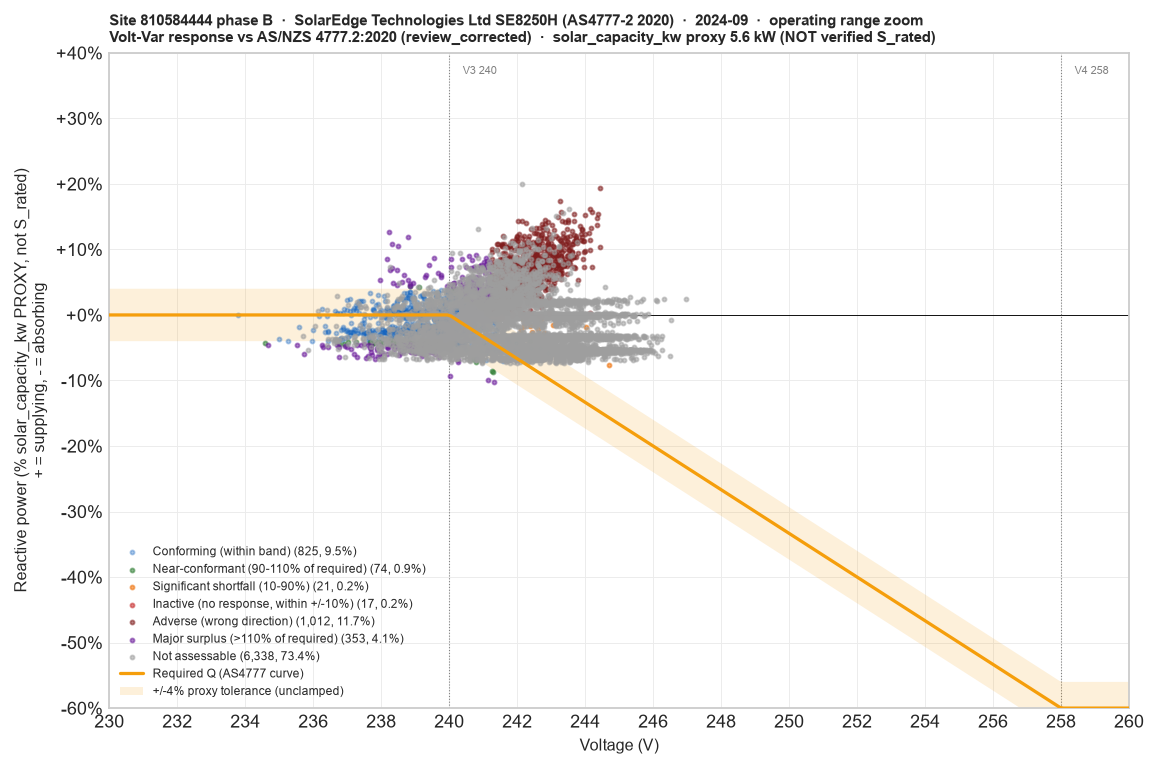

Status breakdown (8,640 intervals total):
  conforming                     825  (  9.5%)
  Q_near_conformant               74  (  0.9%)
  Q_significant_shortfall         21  (  0.2%)
  Q_inactive                      17  (  0.2%)
  Q_adverse                    1,012  ( 11.7%)
  Q_major_surplus                353  (  4.1%)
  not_assessable               6,338  ( 73.4%)

=== Phase C (DER-inferred) ===


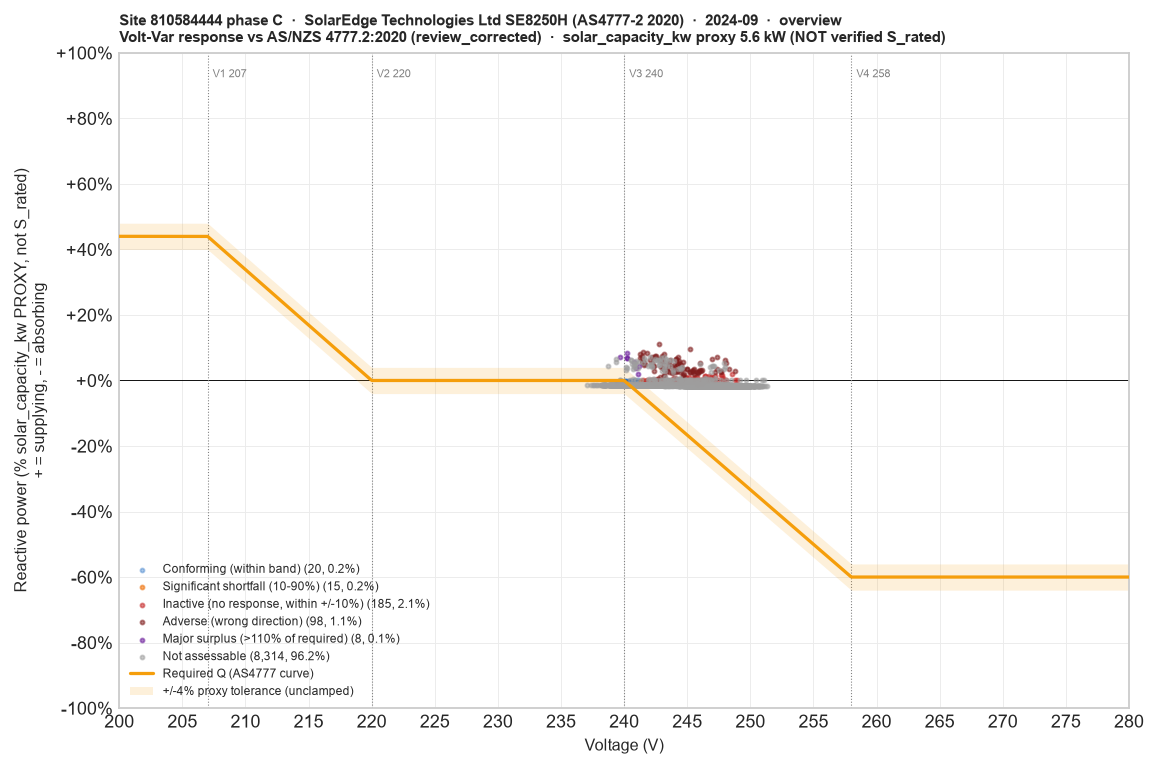

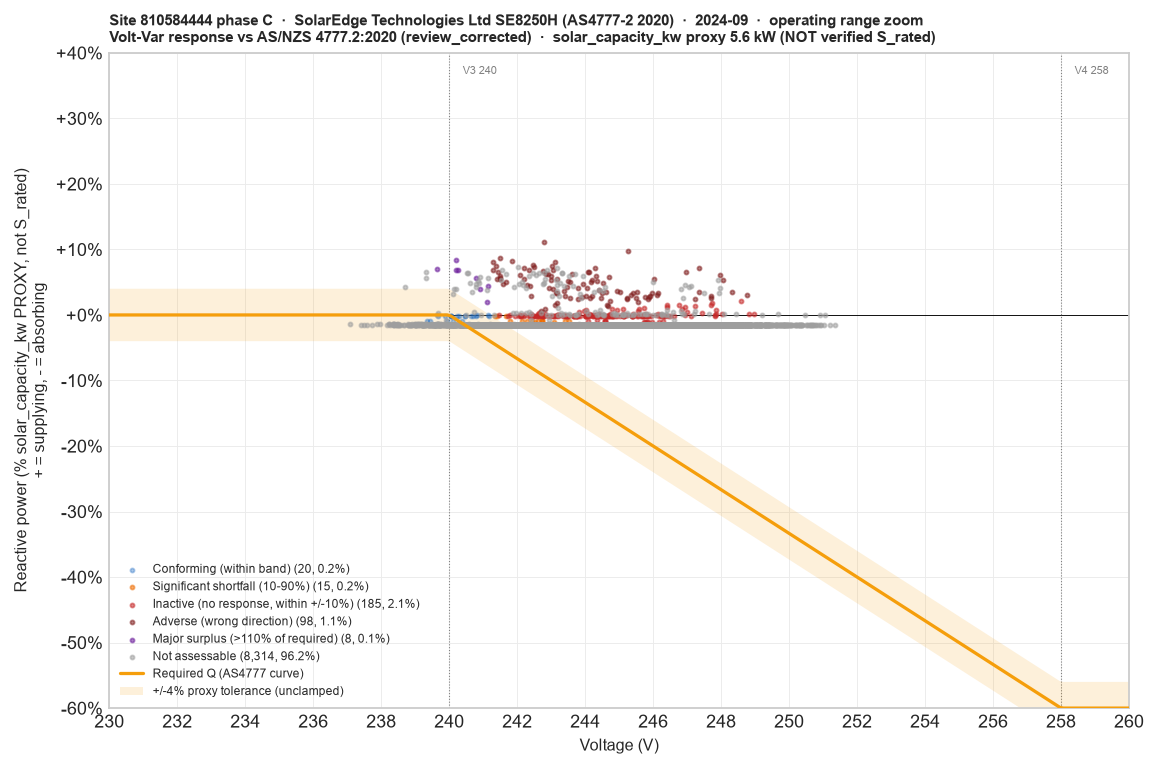

Status breakdown (8,640 intervals total):
  conforming                      20  (  0.2%)
  Q_near_conformant                0  (  0.0%)
  Q_significant_shortfall         15  (  0.2%)
  Q_inactive                     185  (  2.1%)
  Q_adverse                       98  (  1.1%)
  Q_major_surplus                  8  (  0.1%)
  not_assessable               8,314  ( 96.2%)

=== Combined (DER-net across all inferred DER phases) ===


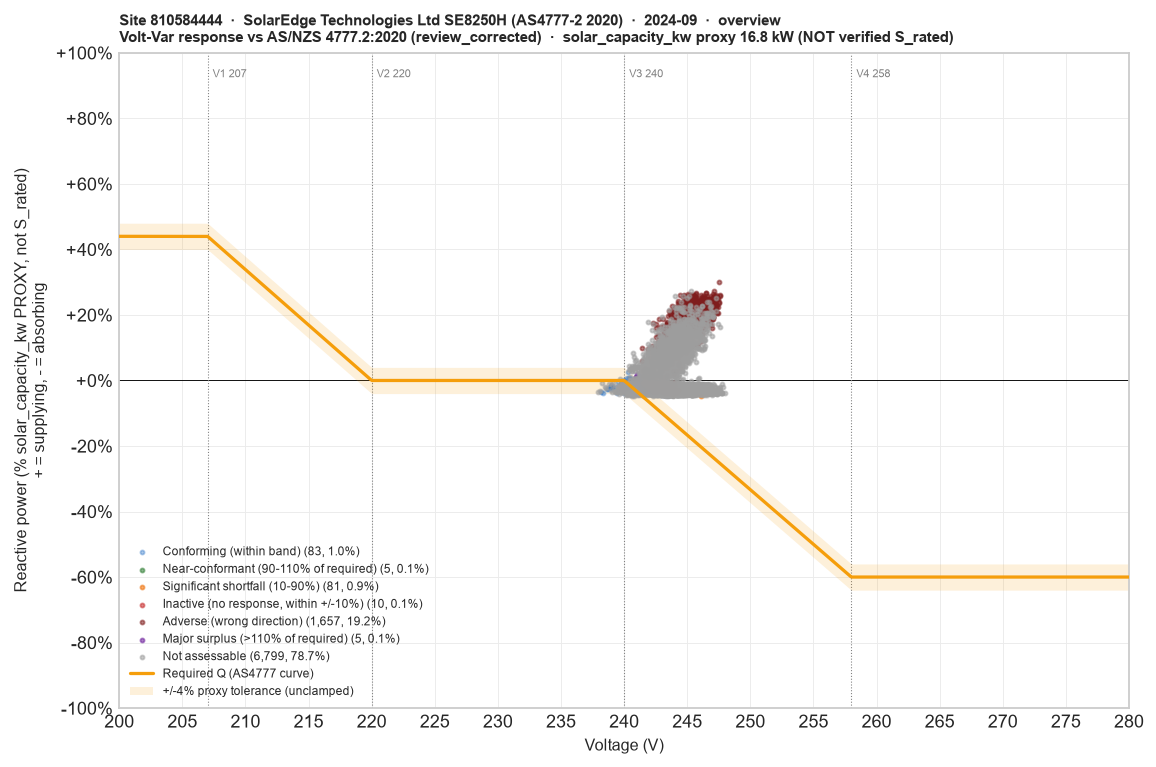

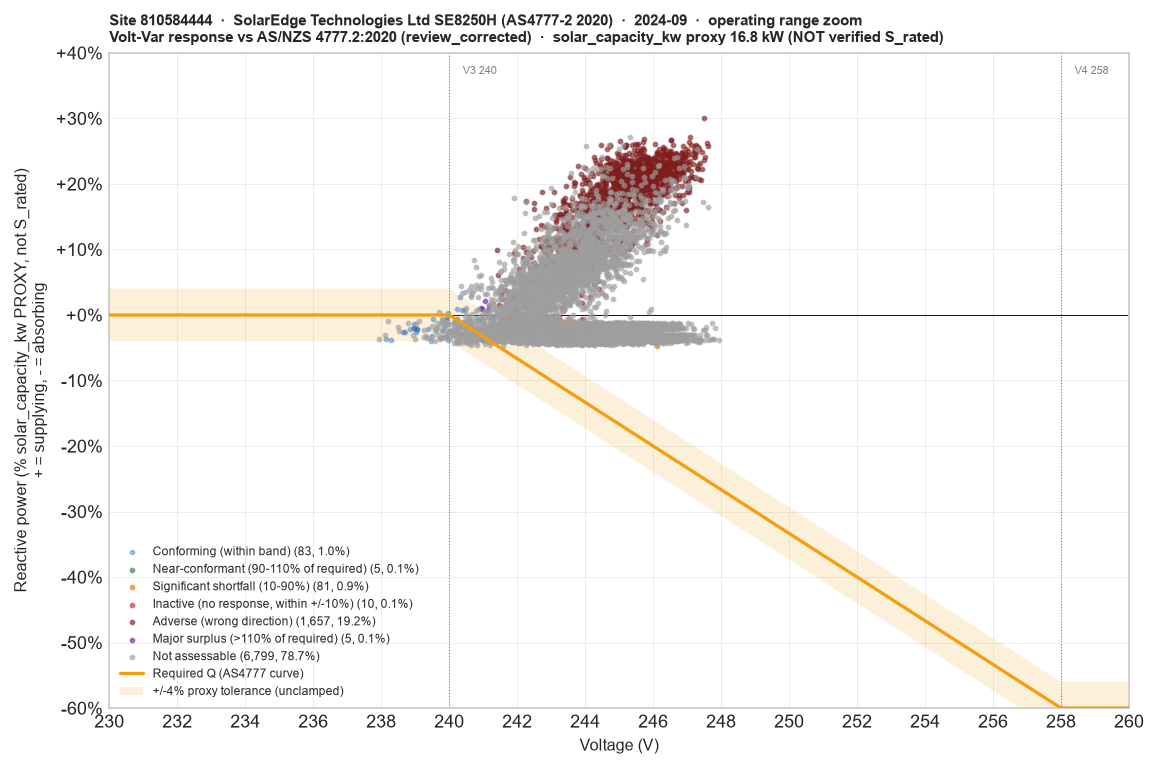

Status breakdown (8,640 intervals total):
  conforming                      83  (  1.0%)
  Q_near_conformant                5  (  0.1%)
  Q_significant_shortfall         81  (  0.9%)
  Q_inactive                      10  (  0.1%)
  Q_adverse                    1,657  ( 19.2%)
  Q_major_surplus                  5  (  0.1%)
  not_assessable               6,799  ( 78.7%)


,V,P_kW,Q_kvar,Q_voltvar,Q_cap_absorbing,capability_assessable,Q_min_final,Q_max_final,Q_impact,status,Q_pct
0,243.847407,2.179920,2.675124,-2.154548,0.000,False,-2.826548,0.672000,NaN,not_assessable,15.923356
1,242.806438,2.195235,2.287129,-1.571605,0.000,False,-2.243605,0.672000,NaN,not_assessable,13.613862
2,242.902634,1.036355,1.853187,-1.625475,0.000,False,-2.297475,0.672000,NaN,not_assessable,11.030875
3,243.521029,1.220142,2.088026,-1.971776,0.000,False,-2.643776,0.672000,NaN,not_assessable,12.428726
4,244.111944,3.190749,2.077816,-2.302688,0.000,False,-2.974688,0.672000,NaN,not_assessable,12.367950
...,...,...,...,...,...,...,...,...,...,...,...
8635,245.994619,6.167079,3.834004,-3.356986,-7.392,True,-4.028986,-2.684987,-1.427941,Q_adverse,22.821451
8636,246.485896,7.474009,4.094369,-3.632102,-7.392,True,-4.304102,-2.960102,-1.383185,Q_adverse,24.371243
8637,246.977183,7.897741,4.130105,-3.907222,-7.392,True,-4.579222,-3.235223,-1.276606,Q_adverse,24.583960
8638,247.097422,6.774598,3.936108,-3.974556,-7.392,True,-4.646556,-3.302556,-1.191837,Q_adverse,23.429213


In [16]:
N_DER_PHASES = len(der_phases) if der_phases else (int(profile['install_phase_count'].iloc[0]) if len(profile) and pd.notna(profile['install_phase_count'].iloc[0]) else 1)
N_DER_PHASES = max(1, N_DER_PHASES)
per_phase_capacity_kw = capacity_kw / N_DER_PHASES
print(f'Splitting {capacity_kw} kW across {N_DER_PHASES} DER-inferred phase(s) '
      f'-> {per_phase_capacity_kw:.2f} kW/phase for the per-phase panels below.')

for ph in sorted(phase_sample['phase'].unique()):
    ph_df = phase_sample[phase_sample['phase'] == ph]
    ph_scatter = pd.DataFrame({
        'V': ph_df['voltage_v'],
        'P_kW': ph_df['p_export_w'] / 1000.0,
        'Q_kvar': -ph_df['q_absorbing_var'] / 1000.0,  # generator convention, same negation used for `sample` earlier
    })
    tag = 'DER-inferred' if ph in der_phases else 'NOT DER-inferred'
    print(f'\n=== Phase {ph} ({tag}) ===')
    plot_vvar_month_scatter_ausgrid(
        ph_scatter, f'{SERIAL} phase {ph}', per_phase_capacity_kw, MONTH,
        capability_profile=CAPABILITY_PROFILE, manufacturer=manufacturer,
    )

print('\n=== Combined (DER-net across all inferred DER phases) ===')
plot_vvar_month_scatter_ausgrid(
    scatter_df, SERIAL, capacity_kw, MONTH,
    capability_profile=CAPABILITY_PROFILE, manufacturer=manufacturer,
)

## Provenance / data-quality context for this site

In [17]:
display(profile)

phase_detail = con.execute(
    'SELECT phase, n_rows, power_measurement_available, solar_signature_w, '
    'solar_capacity_kw, approved_capacity_kw, battery_inverter_capacity_kw '
    'FROM site_phase_profile WHERE serial = ?',
    [str(SERIAL)],
).fetchdf()
display(phase_detail)

n_assessable = int(sample['formal_inverter_conformance_assessable'].sum())
assert n_assessable == 0, 'Expected formal_inverter_conformance_assessable=False on every Delivery 2 row (METHODOLOGY_GATES.md).'
print(f'formal_inverter_conformance_assessable=False on all {len(sample)} rows, as required at this delivery stage.')
print('measurement_basis:', sample['measurement_basis'].unique())
print('voltage_measurement_location:', sample['voltage_measurement_location'].unique())
print('Working signs -- active export:', config.assumptions.active_export_sign,
      '; reactive absorbing:', config.assumptions.reactive_absorbing_sign)
print('Close connection when finished: con.close()')

,serial,metadata_available,analysis_cohort,has_battery,install_phase_count,observed_phase_count,observed_phases,power_phase_count,power_available_phases,inferred_der_phases,phase_mapping_method,phase_mapping_confidence,phase_mapping_sign_dependency,phase_mapping_requires_review,phase_mapping_margin_ratio,top_solar_signature_w,phase_mapping_assessable,solar_only_mapped_cohort,measurement_basis,voltage_measurement_location,formal_inverter_conformance_assessable
0,810584444,True,solar_only,False,3.0,3,A|B|C,3,A|B|C,A|B|C,all_power_available_phases,high,not_sign_ranked,True,NaN,NaN,True,True,net_meter,revenue_meter,False


,phase,n_rows,power_measurement_available,solar_signature_w,solar_capacity_kw,approved_capacity_kw,battery_inverter_capacity_kw
0,A,105120,True,2564.013025,16.799999,20,0.0
1,B,105120,True,-598.653141,16.799999,20,0.0
2,C,105120,True,0.000000,16.799999,20,0.0


formal_inverter_conformance_assessable=False on all 8640 rows, as required at this delivery stage.
measurement_basis: <ArrowStringArray>
['net_meter']
Length: 1, dtype: str
voltage_measurement_location: <ArrowStringArray>
['revenue_meter']
Length: 1, dtype: str
Working signs -- active export: -1 ; reactive absorbing: -1
Close connection when finished: con.close()


## Look at another site

Change `SERIAL` (and optionally `MONTH`/`DATE_FROM`/`DATE_TO`) in the cell
above the site shortlist, then re-run from that cell down through the plots.

In [18]:
# Scratch